K-Nearest Neighbors (KNN) is a classification algorithm that assigns a class label to a data point based on the class labels of its k nearest neighbors in the training set. It is a non-parametric algorithm, which means that it does not make any assumptions about the distribution of the data.

The KNN algorithm works as follows:

Choose a value of k (the number of nearest neighbors to consider).
For each data point in the test set, compute its distance to all data points in the training set.
Select the k nearest neighbors based on their distances.
Assign the class label that appears most frequently among the k nearest neighbors to the test point.
The distance between two data points can be computed using a distance metric such as Euclidean distance, Manhattan distance, or Minkowski distance. The choice of distance metric depends on the nature of the data and the problem at hand.

One important aspect of the KNN algorithm is the choice of the value of k. A small value of k will result in a more flexible decision boundary that can capture complex patterns in the data, but may also lead to overfitting. A large value of k will result in a smoother decision boundary that may not capture fine details in the data, but is less prone to overfitting. The value of k is typically chosen using cross-validation.

KNN can also be used for regression tasks, where the goal is to predict a continuous value instead of a class label. In this case, the predicted value for a test point is the average of the values of its k nearest neighbors in the training set.

In [7]:
import numpy as np
class KNN:
    def __init__(self, k=3, distance = 'euclidean'):
        self.k = k
        self.distance = distance
    
    def fit(self,X,y):
        self.X = X
        self.y = y
    
    def predict(self, X_input):
        # Predict class for each sample in X_input based on K closest neighbors

        classif_assignment = []

        for x in X_input:
            # Compute distance to all points in self.X -> get top k values
            if self.distance == 'euclidean':
                distances = np.linalg.norm(self.X - x, axis=1)
            elif self.distance == 'manhattan':
                distances = np.sum(np.abs(self.X - x), axis=1)
            else:
                distances = np.power(np.sum(np.power(np.abs(self.X - x), self.distance), axis=1), 1/self.distance)
            top_k_class_idxs = np.argsort(distances)[:self.k]
            top_k_values = self.y[top_k_class_idxs]
            # Find the most common label among them, take first one if there are clashing modes
            unique_labels, counts = np.unique(top_k_values, return_counts=True)
            most_common_label = unique_labels[np.argmax(counts)]
            # Assign this label to the test point
            classif_assignment.append(most_common_label)
        
        return np.array(classif_assignment)

In [8]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the iris dataset
iris = load_iris()
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)
# Create a KNN classifier with k=5 and euclidean distance
knn = KNN(k=5, distance='euclidean')
# Train the classifier on the training data
knn.fit(X_train, y_train)
# Make predictions on the test data
y_pred = knn.predict(X_test)
# Compute the accuracy of the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 1.0


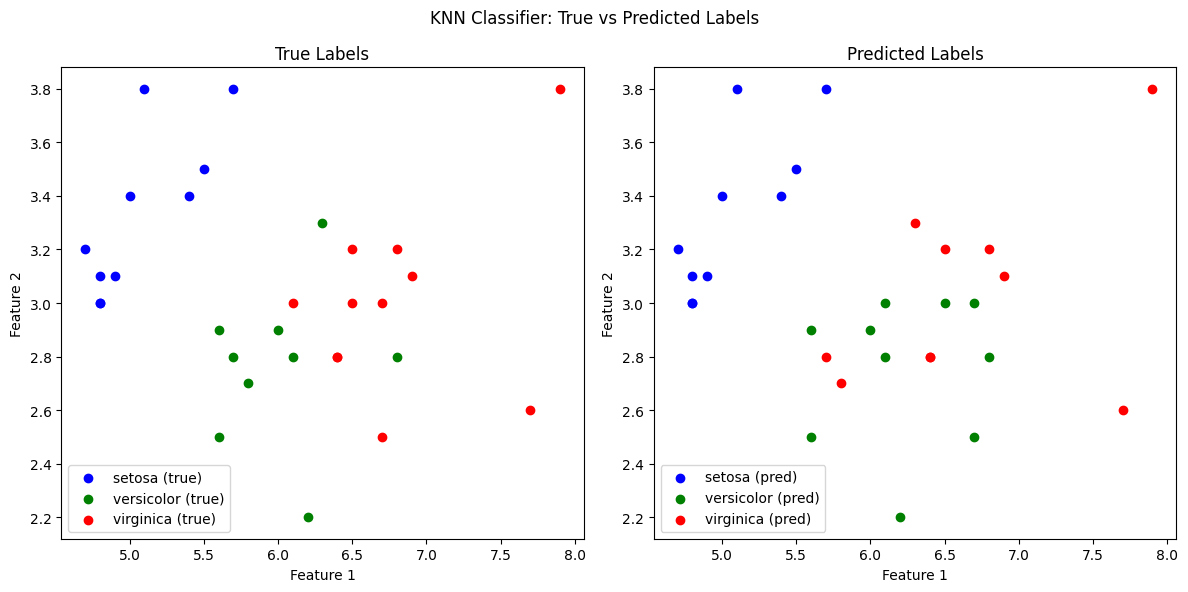

Number predicted as setosa: 10
Number predicted as versicolor: 10
Number predicted as virginica: 10


In [9]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load the iris dataset
iris = load_iris()

# We'll use only the first 2 features for visualization
X = iris.data[:, :2]
y = iris.target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a KNN classifier with k=5 and euclidean distance
knn = KNN(k=5, distance='euclidean')

# Train the classifier
knn.fit(X_train, y_train)

# Make predictions on the test data (Predict per sample)
y_pred = knn.predict(X_test)

# Create side-by-side plots: left = truth, right = predicted
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
for i, color in enumerate(['b', 'g', 'r']):
    axs[0].scatter(X_test[y_test==i, 0], X_test[y_test==i, 1], 
                   c=color, label=f"{iris.target_names[i]} (true)")
axs[0].set_title("True Labels")
axs[0].set_xlabel('Feature 1')
axs[0].set_ylabel('Feature 2')
axs[0].legend()

# Plot predictions
for i, color in enumerate(['b', 'g', 'r']):
    axs[1].scatter(X_test[y_pred==i, 0], X_test[y_pred==i, 1], 
                   c=color, label=f"{iris.target_names[i]} (pred)")
axs[1].set_title("Predicted Labels")
axs[1].set_xlabel('Feature 1')
axs[1].set_ylabel('Feature 2')
axs[1].legend()

plt.suptitle('KNN Classifier: True vs Predicted Labels')
plt.tight_layout()
plt.show()

# Also count the number of predicted samples for each class
from collections import Counter
pred_counts = Counter(y_pred)
for i, name in enumerate(iris.target_names):
    count = pred_counts.get(i, 0)
    print(f"Number predicted as {name}: {count}")
